# 🌞 Benin: Solar Data Profiling, Cleaning & EDA

**Branch:** `eda-benin`  
**Objective:** Profile, clean, and explore Benin's solar dataset end-to-end so it's ready for cross-country comparison and region-ranking tasks.

**Dataset columns:**
| Column | Description |
|--------|-------------|
| Timestamp | Date-time of measurement |
| GHI | Global Horizontal Irradiance (W/m²) |
| DNI | Direct Normal Irradiance (W/m²) |
| DHI | Diffuse Horizontal Irradiance (W/m²) |
| ModA, ModB | Module temperature sensors (°C) |
| Tamb | Ambient temperature (°C) |
| RH | Relative Humidity (%) |
| WS | Wind Speed (m/s) |
| WSgust | Wind Gust Speed (m/s) |
| WD | Wind Direction (°) |
| BP | Barometric Pressure (hPa) |
| Cleaning | Panel cleaning flag (0/1) |
| Precipitation | Precipitation (mm/h) |
| TModA, TModB | Module temperatures (°C) |

**References:**
- [pandas profiling docs](https://pandas.pydata.org/docs/)
- [scipy.stats zscore](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.zscore.html)
- [seaborn heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)
- [windrose library](https://python-windrose.github.io/windrose/)


In [15]:
#import warnings
#warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from pathlib import Path

# Optional: windrose for wind analysis
try:
    from windrose import WindroseAxes
    HAS_WINDROSE = True
except ImportError:
    HAS_WINDROSE = False
    print('windrose not installed — radial bar fallback will be used. pip install windrose')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

COUNTRY = 'benin'
DATA_DIR = Path('E:/project 2026/Cross-Country-Solar-Farm-Analysis/data')
DATA_DIR.mkdir(exist_ok=True)

print('Libraries loaded ✔')


Libraries loaded ✔


# 1. load data 

In [20]:
# ── Load raw CSV ────────────────────────────────────────────────

RAW_PATH = DATA_DIR / 'benin-malanville.csv'   # <── change if needed

if RAW_PATH.exists():
    df = pd.read_csv(RAW_PATH, parse_dates=['Timestamp'])
else:
    raise FileNotFoundError(f"Raw data file not found at {RAW_PATH}. Please check the path and filename.")
print(f"Data loaded from {RAW_PATH} with shape {df.shape}")
df.head()

Data loaded from E:\project 2026\Cross-Country-Solar-Farm-Analysis\data\benin-malanville.csv with shape (525600, 19)


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


## 2.  Summary Statistics & Missing-Value Report

In [17]:
# ── 2.1  Descriptive statistics ─────────────────────────────────
print('=== df.describe() — all numeric columns ===')
df.describe().round(2)

=== df.describe() — all numeric columns ===


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,0.0
mean,2022-02-07 12:00:30,240.56,167.19,115.36,236.59,228.88,28.18,54.49,2.12,2.81,0.47,153.44,8.58,994.20,0.00,0.00,35.25,32.47,NaN
min,2021-08-09 00:01:00,-12.90,-7.80,-12.60,0.00,0.00,11.00,2.10,0.00,0.00,0.00,0.00,0.00,985.00,0.00,0.00,9.00,8.10,NaN
25%,2021-11-08 06:00:45,-2.00,-0.50,-2.10,0.00,0.00,24.20,28.80,1.00,1.30,0.40,59.00,3.70,993.00,0.00,0.00,24.20,23.60,NaN
50%,2022-02-07 12:00:30,1.80,-0.10,1.60,4.50,4.30,28.00,55.10,1.90,2.60,0.50,181.00,8.60,994.00,0.00,0.00,30.00,28.90,NaN
75%,2022-05-09 18:00:15,483.40,314.20,216.30,463.70,447.90,32.30,80.10,3.10,4.10,0.60,235.10,12.30,996.00,0.00,0.00,46.90,41.50,NaN
max,2022-08-09 00:00:00,1413.00,952.30,759.20,1342.30,1342.30,43.80,100.00,19.50,26.60,4.20,360.00,99.40,1003.00,1.00,2.50,81.00,72.50,NaN
std,NaN,331.13,261.71,158.69,326.89,316.54,5.92,28.07,1.60,2.03,0.27,102.33,6.39,2.47,0.03,0.04,14.81,12.35,NaN


In [24]:
print(df.isna().sum())
print (f"Missing values: {df.isna().sum().sum()} total, {df.isna().mean().mean():.2%} overall")

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64
Missing values: 525600 total, 5.26% overall


In [28]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[us]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  int64         
 14  Cleaning       525600 non-null  int64         
 15  Precipitati

## 3 Outlier Detection & Basic Cleaning  for Solar data of Benin
* There are negative values in the data for column of GHI, DNI and DHI  which is impossible in real 
* So that we must set to zeo 

In [29]:
# ── 3.1  Negative irradiance (physically impossible at night → set 0) ──
for col in ['GHI', 'DNI', 'DHI']:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        df[col] = df[col].clip(lower=0)
        print(f'  {col}: clipped {n_neg} negative values → 0')

# Fix obvious sensor errors (e.g. WS = -9999)
for col in ['WS', 'WSgust']:
    if col in df.columns:
        bad = (df[col] < 0).sum()
        df.loc[df[col] < 0, col] = np.nan
        print(f'  {col}: set {bad} impossible negatives → NaN')

  GHI: clipped 258847 negative values → 0
  DNI: clipped 275987 negative values → 0
  DHI: clipped 259182 negative values → 0
  WS: set 0 impossible negatives → NaN
  WSgust: set 0 impossible negatives → NaN


In [30]:
 #── 3.2  Z-score outlier flagging ───────────────────────────────
ZSCORE_COLS = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
ZSCORE_COLS = [c for c in ZSCORE_COLS if c in df.columns]

z_scores = df[ZSCORE_COLS].apply(lambda s: np.abs(stats.zscore(s, nan_policy='omit')))
df['outlier_flag'] = (z_scores > 3).any(axis=1)

outlier_summary = pd.DataFrame({
    'outlier_rows': (z_scores > 3).sum(),
    'outlier_pct':  ((z_scores > 3).sum() / len(df) * 100).round(2)
})

print(f'Total rows flagged as outliers (|Z|>3 in any column): {df["outlier_flag"].sum()} '
      f'({df["outlier_flag"].mean()*100:.2f}%)')
display(outlier_summary)

Total rows flagged as outliers (|Z|>3 in any column): 7893 (1.50%)


,outlier_rows,outlier_pct
GHI,90,0.02
DNI,2,0.00
DHI,3889,0.74
ModA,27,0.01
ModB,63,0.01
WS,3109,0.59
WSgust,3500,0.67


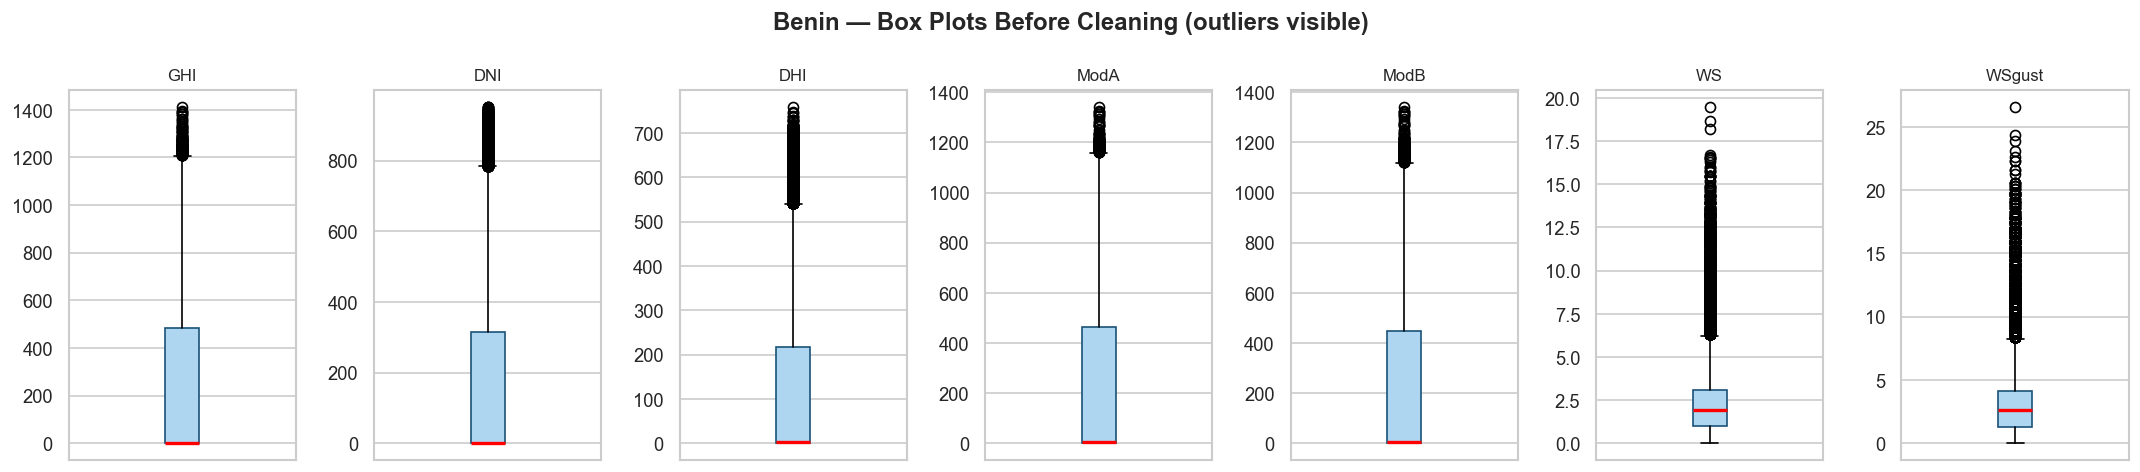

In [31]:
# ── 3.3  Visualise outliers — box plots ─────────────────────────
fig, axes = plt.subplots(1, len(ZSCORE_COLS), figsize=(18, 4))
for ax, col in zip(axes, ZSCORE_COLS):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#AED6F1', color='#1A5276'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=10)
    ax.set_xticks([])
fig.suptitle(f'{COUNTRY.title()} — Box Plots Before Cleaning (outliers visible)', fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# ── 3.4  Impute nulls (median) in key columns ────────────────────
KEY_COLS = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust', 'Tamb', 'RH']
KEY_COLS = [c for c in KEY_COLS if c in df.columns]

imputed = {}
for col in KEY_COLS:
    n_null = df[col].isna().sum()
    if n_null > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        imputed[col] = (n_null, round(median_val, 3))

if imputed:
    print('Median imputation applied:')
    for col, (cnt, med) in imputed.items():
        print(f'  {col}: {cnt} nulls → {med}')
else:
    print('No nulls to impute in key columns.')

No nulls to impute in key columns.


In [6]:
# 2. Outlier Detection & Basic Cleaning
key_columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
print("\n=== Outlier Detection (Z-scores > 3) ===")
for col in key_columns:
    df[f'{col}_zscore'] = np.abs(stats.zscore(df[col], nan_policy='omit'))
outliers = df[df[[f'{col}_zscore' for col in key_columns]].gt(3).any(axis=1)]
print(f"Number of rows with outliers (|Z|>3): {len(outliers)}")


=== Outlier Detection (Z-scores > 3) ===
Number of rows with outliers (|Z|>3): 7740


In [7]:
## Impute missing values in key columns with median
for col in key_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Drop rows with missing Timestamp or other critical non-numeric columns if any
df.dropna(subset=['Timestamp'], inplace=True)


C:\Windows\Temp\ipykernel_1028\1805406148.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Windows\Temp\ipykernel_1028\1805406148.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace m

In [10]:
# Export cleaned DataFrame
if not os.path.exists('output'):
    os.makedirs('output')
df.drop(columns=[f'{col}_zscore' for col in key_columns]).to_csv('output/benin_clean.csv', index=False)
print("\nCleaned data exported to output/benin_clean.csv")



Cleaned data exported to output/benin_clean.csv


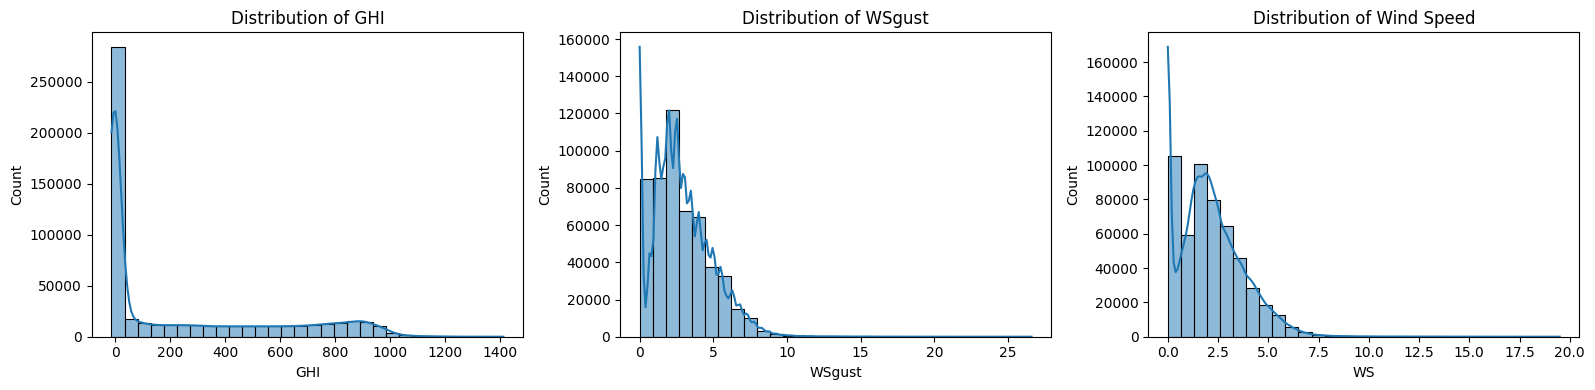

In [12]:
 # Histograms
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['GHI'], bins=30, kde=True)
plt.title('Distribution of GHI')
plt.xlabel('GHI')
plt.subplot(1, 3, 2)
sns.histplot(df['WSgust'], bins=30, kde=True)
plt.title('Distribution of WSgust')
plt.xlabel('WSgust')
plt.subplot(1, 3, 3)
sns.histplot(df['WS'], bins=30, kde=True)
plt.title('Distribution of Wind Speed')
plt.xlabel('WS')
plt.tight_layout()
#plt.savefig('figures/benin/histograms.png')
plt.show()

C:\Windows\Temp\ipykernel_1028\3174404182.py:10: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


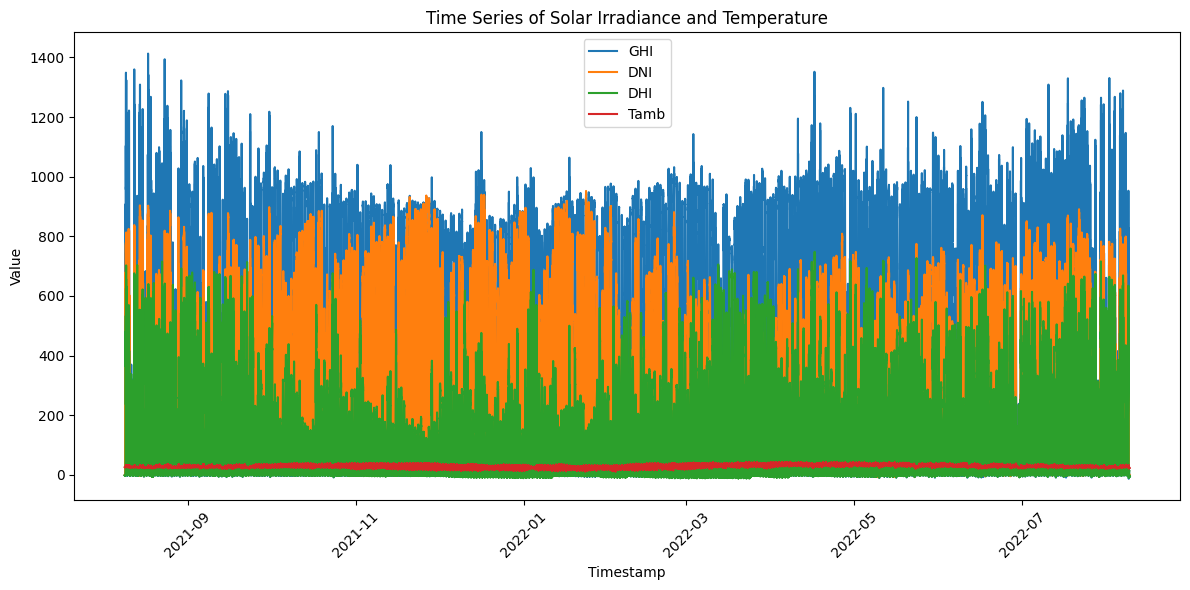

In [14]:
# 3. Time Series Analysis
plt.figure(figsize=(12, 6))
for col in ['GHI', 'DNI', 'DHI', 'Tamb']:
    plt.plot(df['Timestamp'], df[col], label=col)
plt.title('Time Series of Solar Irradiance and Temperature')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('figures/benin/time_series.png')
plt.show()

In [ ]:
# Monthly trends
df['Month'] = df['Timestamp'].dt.month
monthly_avg = df.groupby('Month')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()
monthly_avg.plot(kind='bar', figsize=(12, 6))
plt.title('Monthly Average Solar Irradiance and Temperature')
plt.xlabel('Month')
plt.ylabel('Average Value')
plt.tight_layout()
plt.savefig('figures/benin/monthly_trends.png')
plt.show()

In [ ]:
# 4. Cleaning Impact
cleaning_impact = df.groupby('Cleaning')[['ModA', 'ModB']].mean()
cleaning_impact.plot(kind='bar', figsize=(10, 5))
plt.title('Average ModA and ModB Pre/Post Cleaning')
plt.xlabel('Cleaning (0 = No, 1 = Yes)')
plt.ylabel('Average Value')
plt.tight_layout()
plt.savefig('figures/benin/cleaning_impact.png')
plt.show()

In [ ]:
# 5. Correlation & Relationship Analysis
plt.figure(figsize=(10, 8))
corr = df[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('figures/benin/correlation_heatmap.png')
plt.show()

In [ ]:
# Scatter plots
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(df['WS'], df['GHI'], alpha=0.1)
plt.xlabel('Wind Speed (WS)')
plt.ylabel('GHI')
plt.subplot(1, 3, 2)
plt.scatter(df['WSgust'], df['GHI'], alpha=0.1)
plt.xlabel('Wind Gust (WSgust)')
plt.ylabel('GHI')
plt.subplot(1, 3, 3)
plt.scatter(df['WD'], df['GHI'], alpha=0.1)
plt.xlabel('Wind Direction (WD)')
plt.ylabel('GHI')
plt.tight_layout()
plt.savefig('figures/benin/wind_vs_ghi.png')
plt.show()

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(df['RH'], df['Tamb'], alpha=0.5)
plt.xlabel('Relative Humidity (RH)')
plt.ylabel('Ambient Temperature (Tamb)')
plt.subplot(1, 2, 2)
plt.scatter(df['RH'], df['GHI'], alpha=0.5)
plt.xlabel('Relative Humidity (RH)')
plt.ylabel('GHI')
plt.tight_layout()
plt.savefig('figures/benin/rh_vs_tamb_ghi.png')
plt.show()

In [ ]:
# 6. Wind & Distribution Analysis
# Wind rose plot
fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)
ax.bar(df['WD'], df['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend()
plt.title('Wind Rose Plot (Wind Speed and Direction)')
plt.savefig('figures/benin/wind_rose.png')
plt.show()

In [ ]:
## Temperature Analysis
print("\n=== Temperature and RH Analysis ===")
print("Correlation between RH and Tamb:", df['RH'].corr(df['Tamb']))
print("Correlation between RH and GHI:", df['RH'].corr(df['GHI']))

In [ ]:
# 8. Bubble Chart
plt.figure(figsize=(10, 6))
plt.scatter(df['Tamb'], df['GHI'], s=df['RH']*3, alpha=0.5)
plt.xlabel('Ambient Temperature (Tamb)')
plt.ylabel('GHI')
plt.title('GHI vs. Tamb (Bubble Size = RH)')
plt.tight_layout()
plt.savefig('figures/benin/bubble_chart.png')
plt.show()